# **MNIST Classification using FCNN and CNN in PyTorch**

This tutorial demonstrates how to:

* Load and preprocess the MNIST dataset
* Build two models - FCNN and CNN
* Train and evaluate the models
* Save and load trained models
* Compute confusion matrix, precision, recall, and F1-score
* Plot training loss vs epochs

# **IMPORT LIBRARIES**

In [1]:
import os
# This module provides a portable way of using operating system dependent functionality

import cv2
# powerful tool for processing and analyzing images and videos

import numpy as np
import seaborn as sns
# for creating statistical visualizations

import random as rand
# pseudo-random number generators for various distribution

import matplotlib.pyplot as plt
from glob import glob

from tqdm import tqdm
# provides a fast, extensible progress bar for loops and iterables,
# making it easy to visualize the progress of your code

from sklearn.metrics import confusion_matrix, classification_report

# developed by meta
import torch
from torch import nn, optim, Tensor
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset

# consists of popular datasets, model architectures, and common image transformations for computer vision
import torchvision
from torchvision import transforms

# **SETUP**

In [2]:
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


# **LOAD AND PREPROCESS MNIST DATA**

In [3]:
class MNIST(Dataset):
    def __init__(
            self, 
            num_labels:int, 
            channel:int,
            img_pre_process=None, 
            path_dir:str="MNIST/Images/train", 
            file_ext:str=".jpg"
        )->None:
        super().__init__()
        if channel==1 or channel==3:
            self.channel=channel 
            self.path_dir = path_dir
            self.num_labels = num_labels
            self.img_pre_process = img_pre_process if img_pre_process is not None else transforms.Compose([
                                                                                            transforms.Normalize((0.1307,), (0.3081,))
                                                                                        ])

            if not self.verify_dir():
                raise FileNotFoundError("Unable to find the labels in MNIST")
            
            self.img_path = glob(os.path.join(self.path_dir, f"**/*{file_ext}"))
            self.label = {label:tag for tag, label in enumerate(os.listdir(self.path_dir))}
        else:
            raise ValueError(f"Channel count can only be 1 or 3 not {channel}")
        
    def verify_dir(self,)->bool:
        path_dir = os.listdir(self.path_dir)
        if len(path_dir)==self.num_labels:
            return True
        else:
            return False
    
    def __len__(self):
        return len(self.img_path)
    
    def load_image(self, path:str)->Tensor:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Unable to find the image at path {path}")
        img = cv2.imread(path)
        if self.channel==1:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img/255.0
            img_tensor = torch.from_numpy(img).to(torch.float32)
            img_tensor = torch.unsqueeze(img_tensor, dim=0)

        elif self.channel==3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img/255.0
            size_image = img.shape[0]
            img_tensor = torch.from_numpy(img).to(torch.float32)
            img_tensor = img_tensor.reshape([self.channel, size_image, size_image])

        return self.img_pre_process(img_tensor)

    def __getitem__(self, idx):
        path = self.img_path[idx]
        img_tensor = self.load_image(path)
        label = self.label[path.split("/")[-2]]
        label = torch.tensor(label).to(torch.long)
        return img_tensor, label
        

In [4]:
train_dataset = MNIST(channel=1, num_labels=10, path_dir="MNIST_IMAGE_Data/Data/train", file_ext=".jpg")
test_dataset  = MNIST(channel=1, num_labels=10, path_dir="MNIST_IMAGE_Data/Data/test", file_ext=".jpg")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Training samples: {len(train_dataset)}")
print(f"✅ Testing samples : {len(test_dataset)}")

✅ Training samples: 30360
✅ Testing samples : 7590


# **MODEL DEFINITIONS**

In [5]:
# How bias is neing treated?

class FCNN(nn.Module):
    def __init__(self, input_size=784, num_classes=10):
        super(FCNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# **TRAINING AND TESTING FUNCTIONS**

In [6]:
def train_model(model, train_loader, optimizer, epoch):
    """Train model for one epoch and return average loss"""
    model.train()
    running_loss = 0.0
    for data, target in tqdm(train_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"🧠 Epoch [{epoch}] - Train Loss: {avg_loss:.4f}")
    return avg_loss

@torch.no_grad()
def test_model(model, test_loader):
    """Evaluate model and compute accuracy"""
    model.eval()
    test_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for data, target in tqdm(test_loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            preds = output.argmax(dim=1)
            correct += preds.eq(target).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    test_loss /= len(test_loader.dataset)
    acc = 100. * correct / len(test_loader.dataset)
    print(f"✅ Test Loss: {test_loss:.4f} | Accuracy: {acc:.2f}%")
    return acc, np.array(all_preds), np.array(all_labels)

# **TRAIN FCNN MODEL**

In [7]:
print("\n===============================")
print("🚀 TRAINING FCNN MODEL")
print("===============================")

fcnn_model = FCNN().to(DEVICE)
fcnn_optimizer = optim.Adam(fcnn_model.parameters(), lr=LEARNING_RATE)
fcnn_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_model(fcnn_model, train_loader, fcnn_optimizer, epoch)
    fcnn_losses.append(loss)

torch.save(fcnn_model.state_dict(), "fcnn_mnist.pth")
print("💾 FCNN model saved as 'fcnn_mnist.pth'")

fcnn_acc, fcnn_preds, fcnn_labels = test_model(fcnn_model, test_loader)


🚀 TRAINING FCNN MODEL


100%|██████████| 949/949 [00:14<00:00, 63.78it/s]


🧠 Epoch [1] - Train Loss: 0.3076


100%|██████████| 949/949 [00:07<00:00, 129.55it/s]


🧠 Epoch [2] - Train Loss: 0.1292


...

🧠 Epoch [19] - Train Loss: 0.0168


100%|██████████| 949/949 [00:07<00:00, 134.43it/s]


🧠 Epoch [20] - Train Loss: 0.0174
💾 FCNN model saved as 'fcnn_mnist.pth'


100%|██████████| 238/238 [00:03<00:00, 76.86it/s]

✅ Test Loss: 0.1900 | Accuracy: 96.90%


# **TRAIN CNN MODEL**

In [8]:
print("\n===============================")
print("🚀 TRAINING CNN MODEL")
print("===============================")

cnn_model = SimpleCNN().to(DEVICE)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
cnn_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    loss = train_model(cnn_model, train_loader, cnn_optimizer, epoch)
    cnn_losses.append(loss)

# Save CNN model
torch.save(cnn_model.state_dict(), "cnn_mnist.pth")
print("💾 CNN model saved as 'cnn_mnist.pth'")

# Evaluate CNN
cnn_acc, cnn_preds, cnn_labels = test_model(cnn_model, test_loader)


🚀 TRAINING CNN MODEL


  0%|          | 0/949 [00:00<?, ?it/s]

100%|██████████| 949/949 [00:08<00:00, 116.94it/s]


🧠 Epoch [1] - Train Loss: 0.1707


100%|██████████| 949/949 [00:07<00:00, 125.29it/s]


...

🧠 Epoch [19] - Train Loss: 0.0016


100%|██████████| 949/949 [00:07<00:00, 119.58it/s]


🧠 Epoch [20] - Train Loss: 0.0050
💾 CNN model saved as 'cnn_mnist.pth'


100%|██████████| 238/238 [00:01<00:00, 145.10it/s]

✅ Test Loss: 0.0791 | Accuracy: 98.52%


# **PLOT EPOCH VS LOSS CURVES**

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


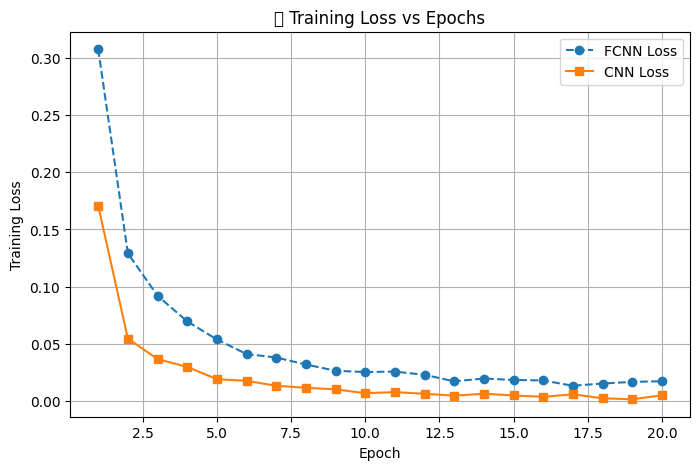

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), fcnn_losses, 'o--', label='FCNN Loss')
plt.plot(range(1, NUM_EPOCHS + 1), cnn_losses, 's-', label='CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('📉 Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

# **EVALUATION: CONFUSION MATRIX & METRICS (CNN)**


📊 CNN MODEL PERFORMANCE METRICS
--------------------------------
              precision    recall  f1-score   support

           0     0.9804    0.9881    0.9843       759
           1     0.9828    0.9802    0.9815       759
           2     0.9906    0.9710    0.9807       759
           3     0.9894    0.9829    0.9861       759
           4     0.9764    0.9829    0.9796       759
           5     0.9831    0.9974    0.9902       759
           6     0.9752    0.9829    0.9790       759
           7     0.9960    0.9934    0.9947       759
           8     0.9855    0.9868    0.9862       759
           9     0.9934    0.9868    0.9901       759

    accuracy                         0.9852      7590
   macro avg     0.9853    0.9852    0.9852      7590
weighted avg     0.9853    0.9852    0.9852      7590



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


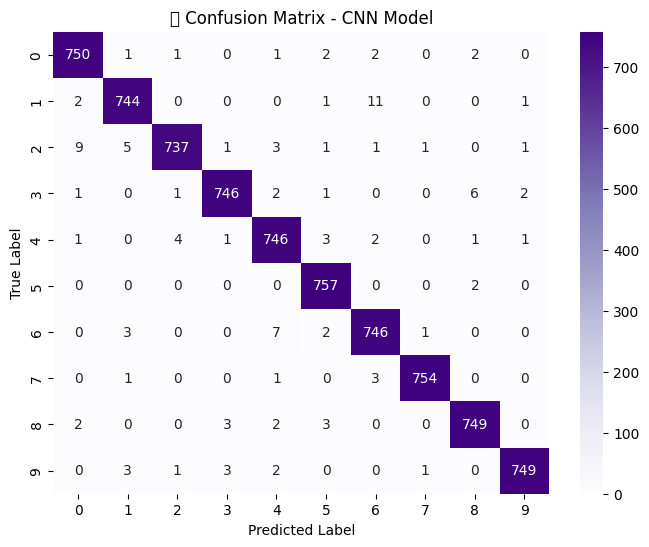

In [10]:
print("\n📊 CNN MODEL PERFORMANCE METRICS")
print("--------------------------------")
print(classification_report(cnn_labels, cnn_preds, digits=4))

cm = confusion_matrix(cnn_labels, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title("🧩 Confusion Matrix - CNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


📊 FCNN MODEL PERFORMANCE METRICS
--------------------------------
              precision    recall  f1-score   support

           0     0.9829    0.9868    0.9849       759
           1     0.9766    0.9908    0.9836       759
           2     0.9527    0.9829    0.9676       759
           3     0.9681    0.9605    0.9643       759
           4     0.9960    0.9789    0.9874       759
           5     0.9678    0.9513    0.9595       759
           6     0.9760    0.9657    0.9709       759
           7     0.9826    0.9684    0.9754       759
           8     0.9510    0.9710    0.9609       759
           9     0.9656    0.9618    0.9637       759

    accuracy                         0.9718      7590
   macro avg     0.9719    0.9718    0.9718      7590
weighted avg     0.9719    0.9718    0.9718      7590



/home/chaitanya-kohli/miniconda3/envs/torch/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


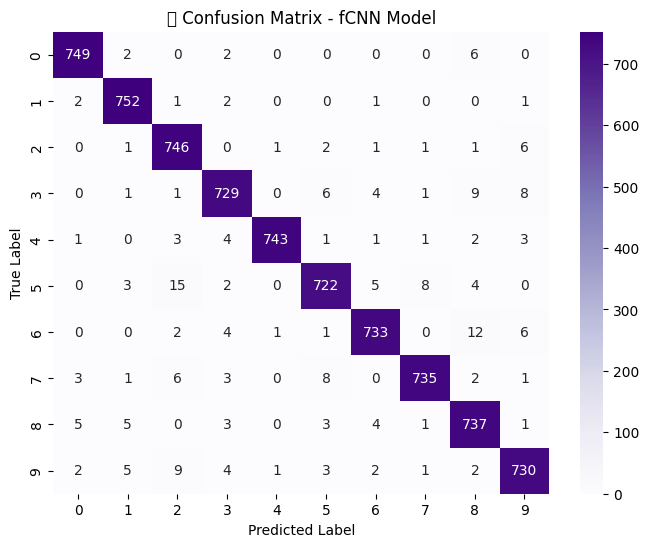

In [ ]:
print("\n📊 FCNN MODEL PERFORMANCE METRICS")
print("--------------------------------")
print(classification_report(fcnn_labels, fcnn_preds, digits=4))

cm = confusion_matrix(fcnn_labels, fcnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title("🧩 Confusion Matrix - fCNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# **LOAD SAVED MODEL & VERIFY**

In [11]:
print("\n📦 Loading saved CNN model and re-evaluating...")
loaded_cnn = SimpleCNN().to(DEVICE)
loaded_cnn.load_state_dict(torch.load("cnn_mnist.pth"))
loaded_cnn.eval()
_, loaded_preds, loaded_labels = test_model(loaded_cnn, test_loader)
print("✅ Model reloaded successfully and produces same accuracy!")


📦 Loading saved CNN model and re-evaluating...


100%|██████████| 238/238 [00:02<00:00, 116.78it/s]

✅ Test Loss: 0.0791 | Accuracy: 98.52%
✅ Model reloaded successfully and produces same accuracy!


# **FINAL RESULTS SUMMARY**

In [12]:
print("\n===============================")
print("🏁 FINAL RESULTS SUMMARY")
print("===============================")
print(f"FCNN Accuracy: {fcnn_acc:.2f}%")
print(f"CNN Accuracy : {cnn_acc:.2f}%")

if cnn_acc > fcnn_acc:
    print("\n🎯 CNN outperforms FCNN — it captures spatial features better!")
else:
    print("\n⚠️ FCNN performed better — try increasing epochs or tuning hyperparameters.")


🏁 FINAL RESULTS SUMMARY
FCNN Accuracy: 96.90%
CNN Accuracy : 98.52%

🎯 CNN outperforms FCNN — it captures spatial features better!
